Research Question and SDG 8

Research question:
Can we predict whether a U.S. adult earns at most $50,000 per year based on their education and employment characteristics?

Connection to SDG 8:
This project connects to SDG 8: Decent Work and Economic Growth because it examines the relationship between education, employment and economic security. Predicting income groups can help labour-market researchers identify patterns associated with lower earnings and investigate which groups may benefit from training or employment support.

The dataset comes from the United States in 1994, so the model should only be used for research and education. It should not automatically decide whether an individual receives financial support, training or employment opportunities.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import zipfile
import urllib.request
import os

# Download the adult.zip file if it doesn't exist
zip_url = "https://archive.ics.uci.edu/static/public/2/adult.zip"
zip_filename = "adult.zip"

if not os.path.exists(zip_filename):
    print(f"Downloading {zip_filename}...")
    urllib.request.urlretrieve(zip_url, zip_filename)
    print("Download complete.")

column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

with zipfile.ZipFile("adult.zip") as zip_file:
    train_data = pd.read_csv(
        zip_file.open("adult.data"),
        names=column_names,
        skipinitialspace=True,
        na_values="?"
    )

    test_data = pd.read_csv(
        zip_file.open("adult.test"),
        names=column_names,
        skiprows=1,
        skipinitialspace=True,
        na_values="?"
    )

print("Training data:", train_data.shape)
print("Test data:", test_data.shape)

train_data.head()

Training data: (32561, 15)
Test data: (16281, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Data Cleaning

The training and test files are combined into one dataset. The income labels are standardised, exact duplicate rows are removed, and columns that are not useful for prediction are dropped. Missing values are not filled yet because this must happen later inside the machine-learning Pipeline.

In [ ]:
# Remove the period from the test income labels
test_data["income"] = test_data["income"].str.rstrip(".")

# Combine both datasets
data = pd.concat([train_data, test_data], ignore_index=True)

print("Shape before cleaning:", data.shape)

# Count and remove exact duplicates
duplicate_count = data.duplicated().sum()
print("Duplicate rows:", duplicate_count)

data = data.drop_duplicates().reset_index(drop=True)

# Drop unnecessary or repeated columns
data = data.drop(columns=["fnlwgt", "education_num"])

print("Shape after cleaning:", data.shape)
print("\nMissing values:")
print(data.isna().sum())

print("\nIncome classes:")
print(data["income"].value_counts())

Shape before cleaning: (48842, 15)
Duplicate rows: 52
Shape after cleaning: (48790, 13)

Missing values:
age                  0
workclass         2795
education            0
marital_status       0
occupation        2805
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     856
income               0
dtype: int64

Income classes:
income
<=50K    37109
>50K     11681
Name: count, dtype: int64


##Exploratory Data Analysis

The cleaned dataset contains 48,790 rows and 13 columns. Missing values occur in workclass, occupation and native_country. These rows are kept because removing all of them could discard useful information. Missing values will later be handled inside the machine-learning Pipeline.

The target is imbalanced: approximately 76% of the observations belong to the <=50K class and 24% belong to the >50K class. Therefore, balanced accuracy will be used as the main evaluation metric.

Income class percentages:
income
<=50K    76.1
>50K     23.9
Name: proportion, dtype: float64


,age,capital_gain,capital_loss,hours_per_week
count,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1080.217688,87.595573,40.425886
std,13.708493,7455.905921,403.209129,12.392729
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


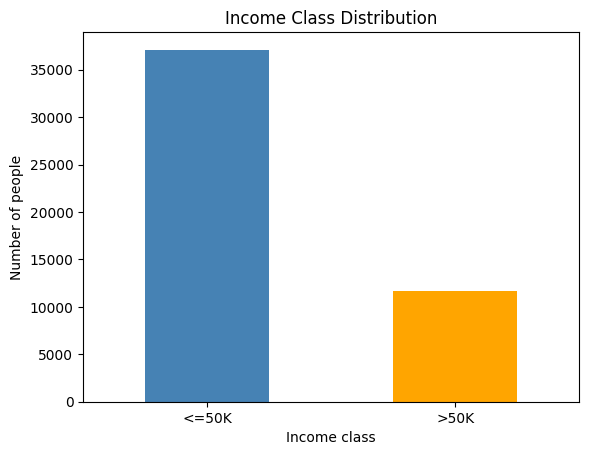

In [ ]:
import matplotlib.pyplot as plt

# Show the percentage of each income class
class_percentages = data["income"].value_counts(normalize=True) * 100
print("Income class percentages:")
print(class_percentages.round(1))

# Show basic statistics for numerical columns
display(data.describe())

# Plot the income class balance
data["income"].value_counts().plot(
    kind="bar",
    color=["steelblue", "orange"]
)

plt.title("Income Class Distribution")
plt.xlabel("Income class")
plt.ylabel("Number of people")
plt.xticks(rotation=0)
plt.show()

### Numerical distributions and unusual values

Age and working hours are examined to understand their distributions and identify impossible values. Unusual values are not removed automatically because an extreme value can still be a valid observation.

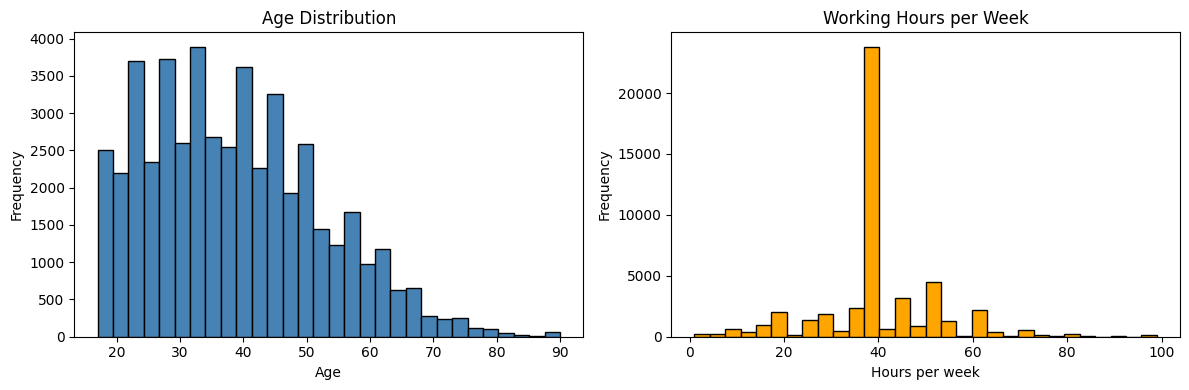

,0
Age below 17,0
Age above 100,0
Working hours equal to 0,0
Working hours above 100,0
Negative capital gain,0
Negative capital loss,0


In [ ]:
# Plot age and working-hours distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data["age"].plot(
    kind="hist",
    bins=30,
    ax=axes[0],
    color="steelblue",
    edgecolor="black"
)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

data["hours_per_week"].plot(
    kind="hist",
    bins=30,
    ax=axes[1],
    color="orange",
    edgecolor="black"
)
axes[1].set_title("Working Hours per Week")
axes[1].set_xlabel("Hours per week")

plt.tight_layout()
plt.show()

# Check for impossible values
value_checks = {
    "Age below 17": (data["age"] < 17).sum(),
    "Age above 100": (data["age"] > 100).sum(),
    "Working hours equal to 0": (data["hours_per_week"] == 0).sum(),
    "Working hours above 100": (data["hours_per_week"] > 100).sum(),
    "Negative capital gain": (data["capital_gain"] < 0).sum(),
    "Negative capital loss": (data["capital_loss"] < 0).sum()
}

pd.Series(value_checks)

### Education, occupation and income

The percentage of people earning more than $50,000 is compared across education and occupation groups. This shows associations in the dataset, but it does not prove that education or occupation causes a particular income.

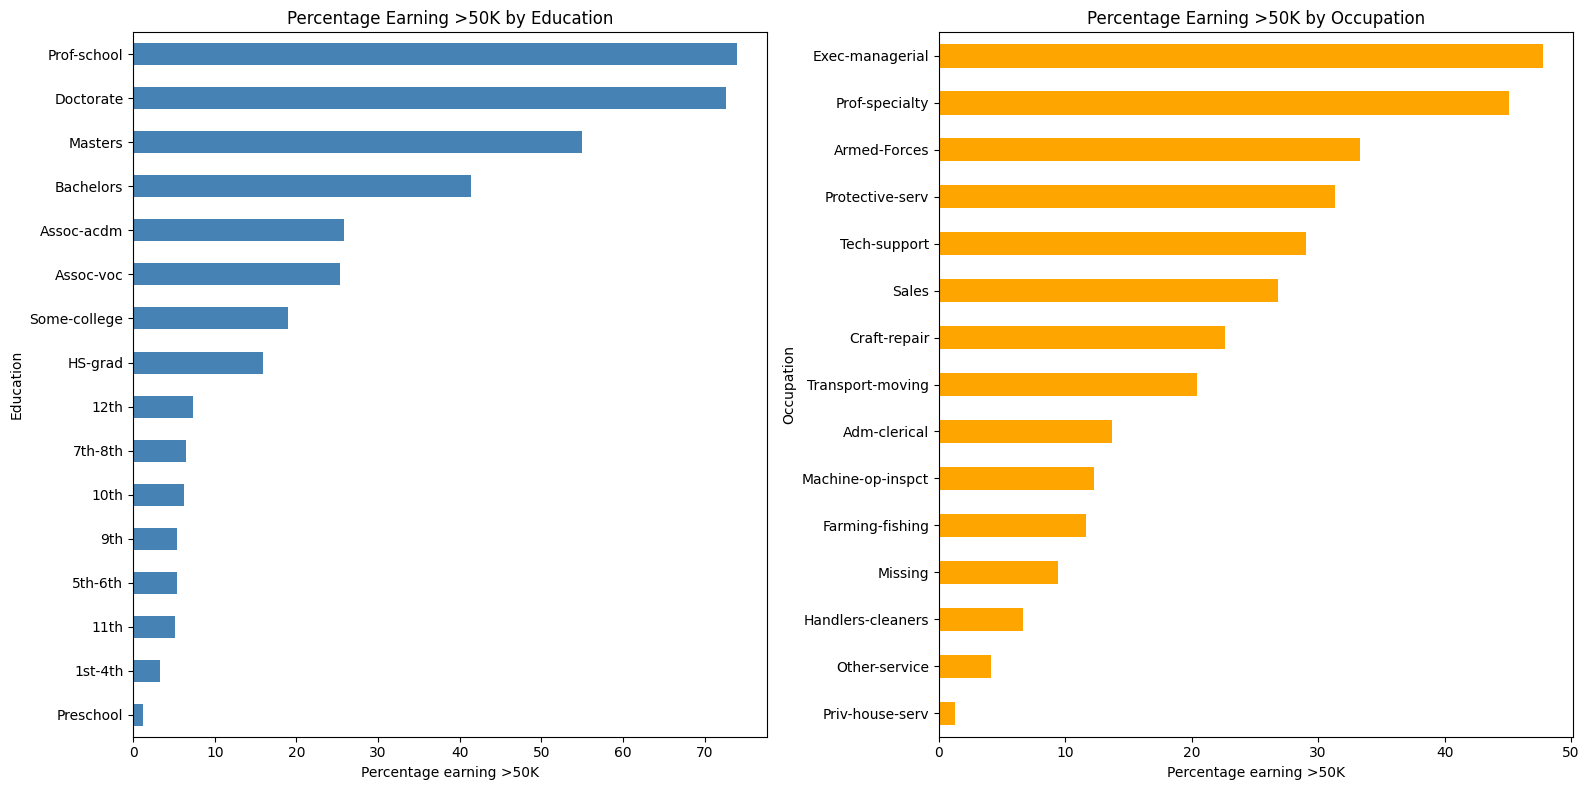

In [ ]:
# Percentage in each income class for every education group
education_income = pd.crosstab(
    data["education"],
    data["income"],
    normalize="index"
) * 100

education_income = education_income.sort_values(by=">50K")

# Use "Missing" temporarily in the graph without changing the original data
occupation_for_plot = data["occupation"].fillna("Missing")

# Percentage in each income class for every occupation group
occupation_income = pd.crosstab(
    occupation_for_plot,
    data["income"],
    normalize="index"
) * 100

occupation_income = occupation_income.sort_values(by=">50K")

# Create the graphs
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

education_income[">50K"].plot(
    kind="barh",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Percentage Earning >50K by Education")
axes[0].set_xlabel("Percentage earning >50K")
axes[0].set_ylabel("Education")

occupation_income[">50K"].plot(
    kind="barh",
    ax=axes[1],
    color="orange"
)
axes[1].set_title("Percentage Earning >50K by Occupation")
axes[1].set_xlabel("Percentage earning >50K")
axes[1].set_ylabel("Occupation")

plt.tight_layout()
plt.show()

### EDA findings

Higher education levels are associated with a larger percentage of people in the >50K income class. Professional-school, doctorate and master's education have the highest percentages.

Executive-managerial and professional-specialty occupations also have relatively high percentages in the >50K class. These results show associations in the 1994 dataset and do not prove that education or occupation causes a higher income. Differences in group size must also be considered.

## Train/Test Split

The target column is separated from the input features. The data is divided into 80% training data and 20% test data. Stratification keeps the income-class proportions similar in both sets. A fixed random state makes the split reproducible.

No missing-value imputation, encoding or scaling is performed before the split. These steps must later be fitted only on the training data inside a Pipeline.

In [ ]:
from sklearn.model_selection import train_test_split

# X contains the input features
X = data.drop(columns=["income"])

# y contains the outcome we want to predict
y = data["income"]

# Create the train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(1))

print("\nTest class percentages:")
print((y_test.value_counts(normalize=True) * 100).round(1))

X_train shape: (39032, 12)
X_test shape: (9758, 12)
y_train shape: (39032,)
y_test shape: (9758,)

Training class percentages:
income
<=50K    76.1
>50K     23.9
Name: proportion, dtype: float64

Test class percentages:
income
<=50K    76.1
>50K     23.9
Name: proportion, dtype: float64


## Build the Preprocessing Pipeline

Numerical features and categorical features require different preprocessing steps. A `ColumnTransformer` is used to apply these transformations separately. Numerical columns are imputed using the median to handle missing values and scaled using a `StandardScaler`. Categorical columns are imputed using the most frequent value and encoded using a `OneHotEncoder`. These preprocessing steps are bundled to prevent data leakage, ensuring they are only fitted on the training data.

In [ ]:
num_cols = ["age", "capital_gain", "capital_loss", "hours_per_week"]
cat_cols = ["workclass", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

## Train and Tune the Models

Four different machine learning models are evaluated: a baseline `DummyClassifier`, K-Nearest Neighbors, Logistic Regression, and a Random Forest. To find the optimal hyperparameters and prevent overfitting, `GridSearchCV` is utilized with 3-fold cross-validation. The preprocessing steps and the classifier are combined inside a `Pipeline` to ensure all data transformations are applied safely and correctly during the cross-validation process.

In [ ]:
# 1. Baseline Model (Dummy)
pipe_dummy = Pipeline(steps=[('preprocessor', preprocessor),
                             ('classifier', DummyClassifier(strategy='most_frequent'))])
pipe_dummy.fit(X_train, y_train)

# 2. K-Nearest Neighbors
pipe_knn = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', KNeighborsClassifier())])
param_grid_knn = {'classifier__n_neighbors': [3, 5, 7]}
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=3, scoring='balanced_accuracy')

# 3. Logistic Regression
pipe_logreg = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(max_iter=1000))])
param_grid_logreg = {'classifier__C': [0.1, 1.0, 10.0]}
grid_logreg = GridSearchCV(pipe_logreg, param_grid_logreg, cv=3, scoring='balanced_accuracy')

# 4. Random Forest
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', RandomForestClassifier(random_state=42))])
param_grid_rf = {'classifier__n_estimators': [50, 100],
                 'classifier__max_depth': [5, 10, None]}
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3, scoring='balanced_accuracy')

# Start tuning
print("Training and tuning models... (This might take a while)")
grid_knn.fit(X_train, y_train)
grid_logreg.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

Training and tuning models... (This might take a while)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'capital_gain',
                                                                          'capital_loss',
                                                                          'hours_per_week']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['workclass',
                                                                          'marital_status',
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'sex',
                                                                          'native_country'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__n_estimators': [50, 100]},
             scoring='balanced_accuracy')

## Evaluate and Compare the Models

The best estimators identified during the grid search are evaluated on the unseen test set. A classification report is generated to compare key metrics such as precision, recall, and balanced accuracy. Additionally, confusion matrices are plotted to visualize the distribution of true and false predictions for each model. Finally, the most robust model is used to predict the income class of a hypothetical new employee.


--- Evaluation for Dummy Classifier (Baseline) ---
              precision    recall  f1-score   support

       <=50K       0.76      1.00      0.86      7422
        >50K       0.00      0.00      0.00      2336

    accuracy                           0.76      9758
   macro avg       0.38      0.50      0.43      9758
weighted avg       0.58      0.76      0.66      9758



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


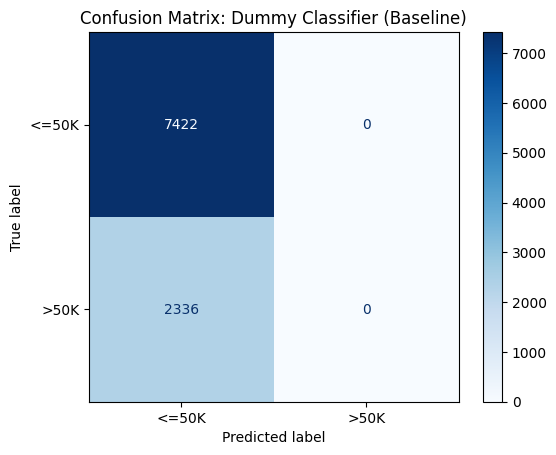


--- Evaluation for K-Nearest Neighbors ---
              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.89      7422
        >50K       0.67      0.60      0.64      2336

    accuracy                           0.84      9758
   macro avg       0.78      0.76      0.77      9758
weighted avg       0.83      0.84      0.83      9758



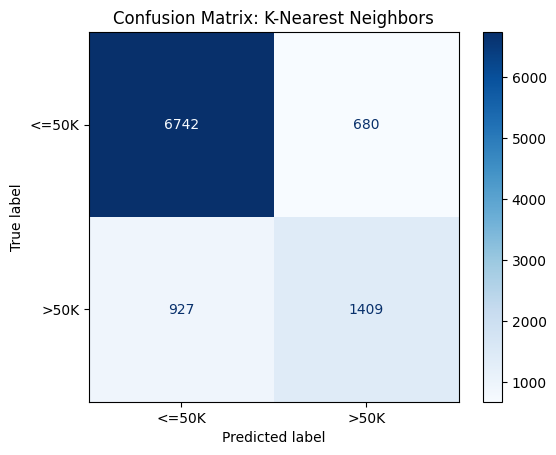


--- Evaluation for Logistic Regression ---
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      7422
        >50K       0.70      0.58      0.64      2336

    accuracy                           0.84      9758
   macro avg       0.79      0.75      0.77      9758
weighted avg       0.83      0.84      0.83      9758



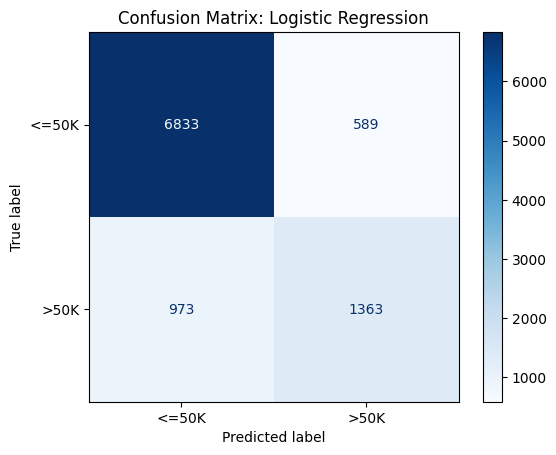


--- Evaluation for Random Forest ---
              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.90      7422
        >50K       0.69      0.62      0.65      2336

    accuracy                           0.84      9758
   macro avg       0.79      0.77      0.78      9758
weighted avg       0.84      0.84      0.84      9758



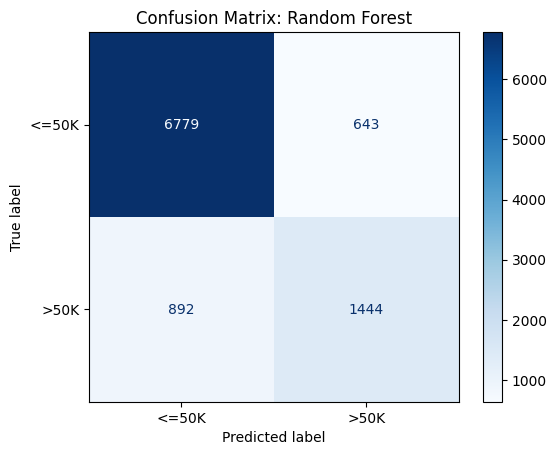


Prediction for new employee: <=50K (with 62.1% certainty)


In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    print(f"\n--- Evaluation for {model_name} ---")
    y_pred = model.predict(X_test)

    # Print classification metrics
    print(classification_report(y_test, y_pred))

    # Plot the confusion matrix
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

# Evaluate all trained models
evaluate_model(pipe_dummy, X_test, y_test, "Dummy Classifier (Baseline)")
evaluate_model(grid_knn.best_estimator_, X_test, y_test, "K-Nearest Neighbors")
evaluate_model(grid_logreg.best_estimator_, X_test, y_test, "Logistic Regression")
evaluate_model(grid_rf.best_estimator_, X_test, y_test, "Random Forest")

# Make a prediction for a new, fictional person with correct column names
new_person = pd.DataFrame([{
    "age": 35,
    "workclass": "Private",
    "education": "Bachelors",
    "marital_status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital_gain": 1500,
    "capital_loss": 0,
    "hours_per_week": 50,
    "native_country": "United-States"
}])

prediction = grid_rf.best_estimator_.predict(new_person)
probability = grid_rf.best_estimator_.predict_proba(new_person).max() * 100
print(f"\nPrediction for new employee: {prediction[0]} (with {probability:.1f}% certainty)")